# Exp 19 — Inference Benchmark

How long does it take to classify one image end-to-end?

**Pipeline:** Load image → CLIP preprocess → CLIP encode → MLP forward → prediction

We time each stage individually and report mean ± std over 100 runs.

In [1]:
import pkg_resources, packaging
pkg_resources.packaging = packaging

import clip
import time
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

PROJECT   = Path(".").resolve().parent
CKPT_PATH = PROJECT / "weights" / "clip_mlp_best.pt"
MANIFEST  = PROJECT / "data" / "frames" / "manifest.csv"

device = (
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available()         else
    "cpu"
)
print(f"Device: {device}")

/var/folders/4x/8gdbr2c547b7s8k94zw4rwmh0000gn/T/ipykernel_63328/2836475392.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources, packaging


Device: mps


## 1 — Load model

In [2]:
# CLIP backbone
clip_model, preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

# MLP head
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
feat_dim = ckpt["feat_dim"]

classifier = nn.Sequential(
    nn.Linear(feat_dim, 256), nn.ReLU(), nn.Dropout(0.0),
    nn.Linear(256, 64),       nn.ReLU(), nn.Dropout(0.0),
    nn.Linear(64, 2),
).to(device)
classifier.load_state_dict(ckpt["state_dict"])
classifier.eval()

label_map_inv = {0: "hidden", 1: "visible"}
print(f"CLIP ViT-B/32 + MLP loaded on {device}")

CLIP ViT-B/32 + MLP loaded on mps


## 2 — Pick test images

In [3]:
df = pd.read_csv(MANIFEST)
df["abs_path"] = df["path"].apply(lambda p: PROJECT / p)
df = df[df["abs_path"].apply(lambda p: p.exists())].reset_index(drop=True)

# Sample 100 random images for benchmarking
sample = df.sample(100, random_state=42)["abs_path"].tolist()
print(f"Benchmark images: {len(sample)}")
print(f"Example: {sample[0]}")

Benchmark images: 100
Example: /Users/siddharthraj/Documents/my-projects/sentiment-analysis/data/frames/visible/2026-04-05_2015_Right_Top_0007-0403_0216.jpg


## 3 — Warmup (MPS / CUDA need a few forward passes to JIT)

In [4]:
def classify(image_path):
    img    = Image.open(image_path).convert("RGB")
    tensor = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = clip_model.encode_image(tensor).float()
        feat = feat / feat.norm(dim=-1, keepdim=True)
        logits = classifier(feat)
        pred   = logits.argmax(dim=1).item()
    return label_map_inv[pred]

# Warmup
for _ in range(5):
    classify(sample[0])
print("Warmup done")

Warmup done


## 4 — Time each stage individually

In [5]:
N = 100
times = {"load": [], "preprocess": [], "clip_encode": [], "mlp": [], "total": []}

for path in sample[:N]:
    t0 = time.perf_counter()

    # Stage 1 — disk load
    img = Image.open(path).convert("RGB")
    t1 = time.perf_counter()

    # Stage 2 — CLIP preprocess (resize, normalize)
    tensor = preprocess(img).unsqueeze(0).to(device)
    t2 = time.perf_counter()

    # Stage 3 — CLIP encode
    with torch.no_grad():
        feat = clip_model.encode_image(tensor).float()
        feat = feat / feat.norm(dim=-1, keepdim=True)
    if device == "mps":
        torch.mps.synchronize()
    t3 = time.perf_counter()

    # Stage 4 — MLP forward
    with torch.no_grad():
        logits = classifier(feat)
        pred   = logits.argmax(dim=1).item()
    if device == "mps":
        torch.mps.synchronize()
    t4 = time.perf_counter()

    times["load"].append((t1 - t0) * 1000)
    times["preprocess"].append((t2 - t1) * 1000)
    times["clip_encode"].append((t3 - t2) * 1000)
    times["mlp"].append((t4 - t3) * 1000)
    times["total"].append((t4 - t0) * 1000)

print(f"{'Stage':<15} {'Mean (ms)':>10} {'Std (ms)':>10} {'Min (ms)':>10} {'Max (ms)':>10}")
print("-" * 55)
for stage, vals in times.items():
    arr = np.array(vals)
    print(f"{stage:<15} {arr.mean():>10.2f} {arr.std():>10.2f} {arr.min():>10.2f} {arr.max():>10.2f}")

Stage            Mean (ms)   Std (ms)   Min (ms)   Max (ms)
-------------------------------------------------------
load                 13.90       3.05       8.49      20.61
preprocess           18.09       1.57      14.32      27.02
clip_encode           9.02       2.98       4.37      15.68
mlp                   0.58       0.16       0.37       1.54
total                41.59       5.51      27.81      59.43


## 5 — Throughput: how many images per second?

In [6]:
mean_total_ms = np.mean(times["total"])
fps = 1000 / mean_total_ms
print(f"Mean end-to-end latency : {mean_total_ms:.1f} ms / image")
print(f"Throughput              : {fps:.1f} images / second")
print()

# Context: aquarium cameras record at ~?
for fps_cam in [1, 5, 10, 25, 30]:
    ratio = fps / fps_cam
    status = "✓ real-time" if ratio >= 1 else "✗ too slow"
    print(f"  At {fps_cam:2d} fps camera: {ratio:.1f}x faster than real-time  {status}")

Mean end-to-end latency : 41.6 ms / image
Throughput              : 24.0 images / second

  At  1 fps camera: 24.0x faster than real-time  ✓ real-time
  At  5 fps camera: 4.8x faster than real-time  ✓ real-time
  At 10 fps camera: 2.4x faster than real-time  ✓ real-time
  At 25 fps camera: 1.0x faster than real-time  ✗ too slow
  At 30 fps camera: 0.8x faster than real-time  ✗ too slow


## 6 — Batch inference (how fast with batching?)

In [7]:
batch_sizes = [1, 4, 8, 16, 32]
batch_results = []

imgs_preloaded = [preprocess(Image.open(p).convert("RGB")) for p in sample[:32]]

for bs in batch_sizes:
    batch = torch.stack(imgs_preloaded[:bs]).to(device)
    # warmup
    for _ in range(3):
        with torch.no_grad():
            f = clip_model.encode_image(batch).float()
            f = f / f.norm(dim=-1, keepdim=True)
            classifier(f)

    runs = []
    for _ in range(20):
        t0 = time.perf_counter()
        with torch.no_grad():
            f = clip_model.encode_image(batch).float()
            f = f / f.norm(dim=-1, keepdim=True)
            classifier(f)
        if device == "mps":
            torch.mps.synchronize()
        runs.append((time.perf_counter() - t0) * 1000)

    mean_ms  = np.mean(runs)
    per_img  = mean_ms / bs
    throughput = 1000 / per_img
    batch_results.append({"batch_size": bs, "total_ms": mean_ms, "per_image_ms": per_img, "imgs_per_sec": throughput})
    print(f"batch={bs:2d}  total={mean_ms:6.1f}ms  per_img={per_img:5.1f}ms  {throughput:.0f} img/s")

batch_df = pd.DataFrame(batch_results)
batch_df

batch= 1  total=   4.7ms  per_img=  4.7ms  211 img/s
batch= 4  total=  13.1ms  per_img=  3.3ms  306 img/s
batch= 8  total=  18.5ms  per_img=  2.3ms  432 img/s
batch=16  total=  34.7ms  per_img=  2.2ms  462 img/s
batch=32  total=  64.9ms  per_img=  2.0ms  493 img/s


,batch_size,total_ms,per_image_ms,imgs_per_sec
0,1,4.735552,4.735552,211.168613
1,4,13.080542,3.270135,305.797732
2,8,18.519142,2.314893,431.985462
3,16,34.652131,2.165758,461.732062
4,32,64.878481,2.027453,493.229795


## 7 — Visualise breakdown

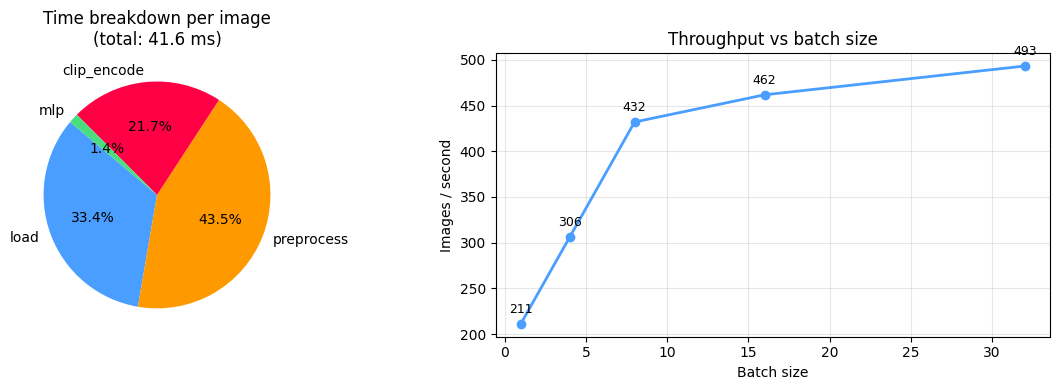

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Stage breakdown pie
stages = ["load", "preprocess", "clip_encode", "mlp"]
means  = [np.mean(times[s]) for s in stages]
colors = ["#4a9eff", "#f90", "#f04", "#4ade80"]
axes[0].pie(means, labels=stages, colors=colors, autopct="%1.1f%%", startangle=140)
axes[0].set_title(f"Time breakdown per image\n(total: {np.mean(times['total']):.1f} ms)")

# Batch throughput
axes[1].plot(batch_df["batch_size"], batch_df["imgs_per_sec"], marker="o", color="#4a9eff", linewidth=2)
axes[1].set_xlabel("Batch size")
axes[1].set_ylabel("Images / second")
axes[1].set_title("Throughput vs batch size")
axes[1].grid(alpha=0.3)
for _, row in batch_df.iterrows():
    axes[1].annotate(f"{row['imgs_per_sec']:.0f}",
                     (row["batch_size"], row["imgs_per_sec"]),
                     textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT / "data" / "frames" / "inference_benchmark.png", dpi=120, bbox_inches="tight")
plt.show()